# smelt-bench

In [1]:
import os

if "COLAB_GPU" in os.environ:
    if not os.path.exists("smelt"):
        os.system("git clone https://github.com/PritRaj1/smelt.git")
    os.chdir("smelt")
    os.system("pip install -q -e '.[bench]'")
    os.system("python -c 'from smelt._clib import load_lib; load_lib()'")
else:
    os.chdir(os.path.join(os.path.dirname(os.getcwd())))

print(f"cwd: {os.getcwd()}")

cwd: /content/smelt


In [2]:
MODEL = "gpt2"
OUT = "benches/bench_results.json"
PP = 8
TG = 16

!rm -f {OUT}

In [3]:
!python benches/bench.py run -m smelt --model {MODEL} -p {PP} -n {TG} -o {OUT}

method: smelt  model: gpt2
pp=8 tg=16  hw: {'cpu': 'x86_64', 'cores': 1, 'ram_gb': 13.6, 'gpu': 'Tesla T4', 'vram_gb': 15.6}

config.json: 100% 665/665 [00:00<00:00, 2.18MB/s]
`torch_dtype` is deprecated! Use `dtype` instead!
model.safetensors: 100% 548M/548M [00:03<00:00, 170MB/s]
Loading weights: 100% 148/148 [00:00<00:00, 1143.87it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
generation_config.json: 100% 124/124 [00:00<00:00, 408kB/s]
tokenizer_config.json: 100% 26.0/26.0 [00:00<00:00, 127kB/s]
vocab.json: 1.04MB [00:00, 47.7MB/s]
merges.txt: 456kB [00:00, 1.74MB/s]
tokenizer.json: 1.36MB [00:00, 30.3MB/s]
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected be

In [4]:
!python benches/bench.py run -m hf-gpu --model {MODEL} -p {PP} -n {TG} -o {OUT}

method: hf-gpu  model: gpt2
pp=8 tg=16  hw: {'cpu': 'x86_64', 'cores': 1, 'ram_gb': 13.6, 'gpu': 'Tesla T4', 'vram_gb': 15.6}

`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100% 148/148 [00:00<00:00, 1887.64it/s, Materializing param=transformer.wte.weight]
GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attent

In [5]:
!python benches/bench.py plot {OUT}

saved benches/benchmark.png

method                 pp tok/s   tg tok/s     mem MB
-----------------------------------------------------
smelt                      62.3       33.3       1136
hf-gpu                    817.8       92.6        268


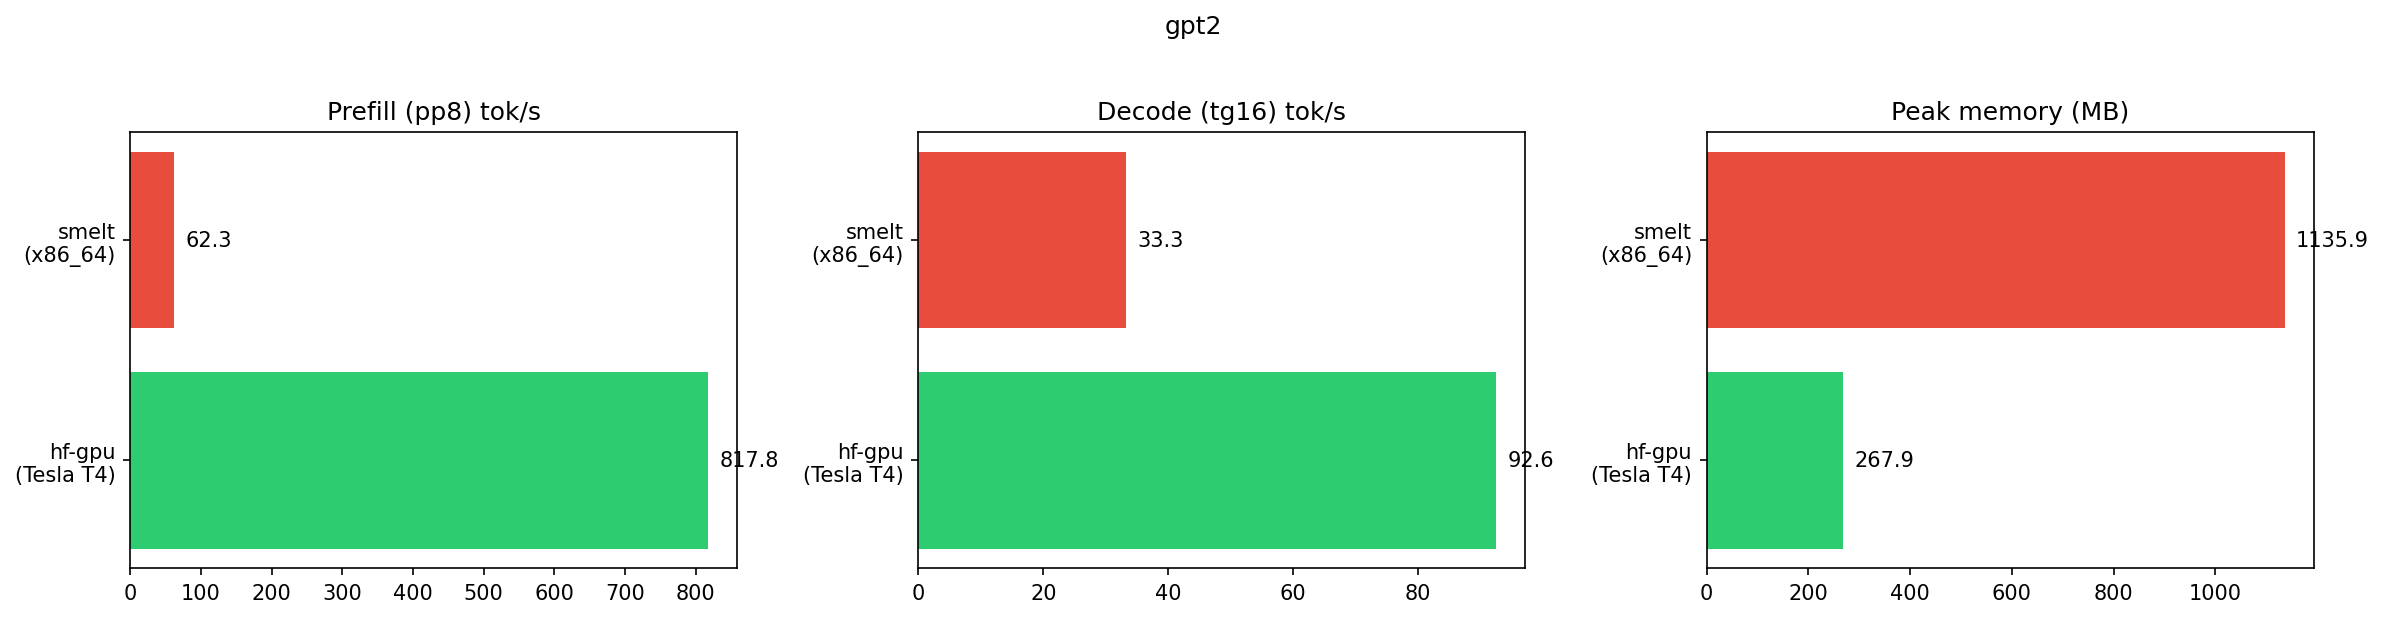

In [6]:
from IPython.display import Image

Image("benches/benchmark.png")